In [1]:
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
# Load dataset
iris = load_iris()

# Features
X = iris.data

# Target labels
y = iris.target

In [3]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species  
0          0

In [4]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
df["species_name"] = df["species"].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


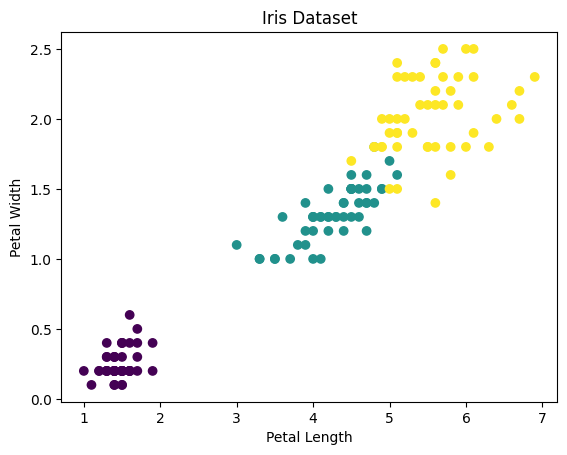

In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    df["petal length (cm)"], 
    df["petal width (cm)"], 
    c=y
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset")
plt.show()

In [7]:
from sklearn.datasets import load_iris
import pandas as pd
import plotly.express as px

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target
df["species_name"] = df["species"].map(
    {i: name for i, name in enumerate(iris.target_names)}
)

# Interactive scatter plot
fig = px.scatter(
    df,
    x="petal length (cm)",
    y="petal width (cm)",
    color="species_name",
    title="Iris Dataset - Interactive Plot",
    labels={
        "petal length (cm)": "Petal Length (cm)",
        "petal width (cm)": "Petal Width (cm)",
        "species_name": "Species"
    }
)

fig.show()

In [8]:
fig = px.scatter_3d(
    df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    z="petal length (cm)",
    color="species_name",
    title="Iris Dataset - 3D Interactive Plot"
)

fig.show()

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import plotly.express as px
import pandas as pd

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame (for labels)
cm_df = pd.DataFrame(
    cm,
    index=iris.target_names,
    columns=iris.target_names
)

# Heatmap
fig = px.imshow(
    cm_df,
    text_auto=True,
    labels=dict(x="Predicted", y="Actual", color="Count"),
    title="Confusion Matrix Heatmap"
)

fig.show()